# Modelos CNN

## Importar librerías

In [ ]:
# Librerías básicas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
import shutil
import zipfile

# Librerías para el preprocesamiento de datos
import kagglehub
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Librerías para el modelado
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Librerías para la evaluación de modelos
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

2026-03-12 11:40:34.542767: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Clasificación Birds VS Drone

## Cargar datos

In [2]:
# Directorio de trabajo actual
dest_dir = Path(os.getcwd())

# Descargar dataset (devuelve la ruta donde se descargó)
path = kagglehub.dataset_download("stealthknight/bird-vs-drone")

print(f"Dataset descargado en: {path}")

Dataset descargado en: /root/.cache/kagglehub/datasets/stealthknight/bird-vs-drone/versions/1


In [3]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"✅ GPU disponible: {len(gpus)}")
    for i, gpu in enumerate(gpus):
        print(f"GPU {i}: {gpu.name}")
else:
    print("⚠️ No hay GPU disponible, se usará CPU")

✅ GPU disponible: 1
GPU 0: /physical_device:GPU:0


2026-03-12 11:40:36.398976: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-12 11:40:36.405206: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-12 11:40:36.406551: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## Preparar datasets

In [4]:
# Configuración de paths
dataset_root = dataset_dir if "dataset_dir" in globals() else Path(path) / "Dataset"
train_dir = dataset_root / "train"
val_dir   = dataset_root / "valid"
test_dir  = dataset_root / "test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32


def infer_label_from_filename(image_path):
    """Inferencia por nombre de archivo: B* -> bird(0), D* -> drone(1)."""
    stem_upper = image_path.stem.strip().upper()
    if stem_upper.startswith("B"):
        return 0
    if stem_upper.startswith("D"):
        return 1
    raise ValueError(f"No se pudo inferir clase por nombre en {image_path.name}")


def parse_label_file(label_path, image_path):
    """Parsea etiquetas tipo texto (bird/drone), YOLO (0/1 ...), o fallback por nombre."""
    content = label_path.read_text(encoding="utf-8").strip()

    if not content:
        return infer_label_from_filename(image_path), "filename_fallback"

    first_line = content.splitlines()[0].strip()
    first_token = first_line.split()[0].lower()

    name_to_id = {"bird": 0, "drone": 1}
    if first_token in name_to_id:
        return name_to_id[first_token], "label_text"

    try:
        class_id = int(float(first_token))
    except ValueError as err:
        raise ValueError(
            f"No se pudo parsear etiqueta en {label_path}. "
            f"Primer token: '{first_token}'"
        ) from err

    if class_id not in (0, 1):
        raise ValueError(f"Clase fuera de rango en {label_path}: {class_id}")

    return class_id, "label_yolo"


def create_tf_dataset(split_dir, shuffle=False, seed=42):
    image_dir = split_dir / "images"
    label_dir = split_dir / "labels"

    img_paths = sorted(
        list(image_dir.glob("*.jpg"))
        + list(image_dir.glob("*.jpeg"))
        + list(image_dir.glob("*.png"))
    )
    label_paths = sorted(label_dir.glob("*.txt"))

    label_by_stem = {p.stem: p for p in label_paths}

    image_files = []
    labels = []
    missing_labels = []
    source_counts = {"label_text": 0, "label_yolo": 0, "filename_fallback": 0}

    for img_path in img_paths:
        label_path = label_by_stem.get(img_path.stem)
        if label_path is None:
            missing_labels.append(img_path.name)
            continue

        class_id, source = parse_label_file(label_path, img_path)
        image_files.append(str(img_path))
        labels.append(class_id)
        source_counts[source] += 1

    if missing_labels:
        preview = ", ".join(missing_labels[:5])
        raise ValueError(
            f"Faltan etiquetas para {len(missing_labels)} imágenes en {split_dir.name}. "
            f"Ejemplos: {preview}"
        )

    if not image_files:
        raise ValueError(f"No se encontraron pares imagen-etiqueta válidos en {split_dir}")

    labels_np = np.array(labels, dtype=np.int32)
    class_counts = np.bincount(labels_np, minlength=2)
    print(
        f"[{split_dir.name}] total={len(image_files)} | "
        f"bird(0)={class_counts[0]} | drone(1)={class_counts[1]}"
    )
    print(
        f"[{split_dir.name}] fuente etiquetas -> "
        f"texto={source_counts['label_text']} | "
        f"yolo={source_counts['label_yolo']} | "
        f"fallback_nombre={source_counts['filename_fallback']}"
    )

    ds = tf.data.Dataset.from_tensor_slices((image_files, labels_np))

    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_files), seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


# Crear datasets
train_ds = create_tf_dataset(train_dir, shuffle=True)
val_ds   = create_tf_dataset(val_dir, shuffle=False)
test_ds  = create_tf_dataset(test_dir, shuffle=False)

[train] total=18323 | bird(0)=18320 | drone(1)=3
[train] fuente etiquetas -> texto=0 | yolo=18306 | fallback_nombre=17


2026-03-12 11:40:37.348719: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-12 11:40:37.350665: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-12 11:40:37.351672: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

[valid] total=1740 | bird(0)=1739 | drone(1)=1
[valid] fuente etiquetas -> texto=0 | yolo=1737 | fallback_nombre=3
[test] total=889 | bird(0)=798 | drone(1)=91
[test] fuente etiquetas -> texto=0 | yolo=886 | fallback_nombre=3


In [5]:
def get_model(model_name, input_shape=(224,224,3), num_classes=2):
    if model_name=="ResNet50":
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name=="MobileNetV2":
        from tensorflow.keras.applications import MobileNetV2
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name=="EfficientNetB0":
        from tensorflow.keras.applications import EfficientNetB0
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    
    base.trainable = False  # freeze pre-trained layers
    
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Sistema de registro de experimentos

In [6]:
# ── Registro de experimentos ────────────────────────────────────────────────
experiment_registry = []
history_registry    = {}

def run_experiment(model_name, train_ds, val_ds, test_ds, epochs=5):
    """Entrena un modelo, evalúa y registra resultados."""
    print(f"\n{'='*50}")
    print(f"  Experimento: {model_name}")
    print(f"{'='*50}")

    model = get_model(model_name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    # Predicciones para métricas adicionales
    y_pred, y_true = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    record = {
        'model':     model_name,
        'epochs':    epochs,
        'test_loss': round(loss, 4),
        'test_acc':  round(acc,  4),
        'val_acc':   round(max(history.history['val_accuracy']), 4),
        'val_loss':  round(min(history.history['val_loss']),     4),
    }

    experiment_registry.append(record)
    history_registry[model_name] = history.history

    print(f"✅ {model_name} → Acc: {acc:.4f} | Loss: {loss:.4f}")
    return model, y_true, y_pred


In [7]:
# ── Ejecutar todos los modelos ───────────────────────────────────────────────
models_to_test = ["ResNet50", "MobileNetV2", "EfficientNetB0"]
predictions_registry = {}

for model_name in models_to_test:
    model, y_true, y_pred = run_experiment(
        model_name, train_ds, val_ds, test_ds, epochs=5
    )
    predictions_registry[model_name] = {'y_true': y_true, 'y_pred': y_pred}



  Experimento: ResNet50
Epoch 1/5


I0000 00:00:1773315649.223883    3269 service.cc:145] XLA service 0x7c9f40002e70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773315649.223902    3269 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-03-12 11:40:49.388265: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-12 11:40:50.218361: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8906
I0000 00:00:1773315651.500575    3353 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_9024', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1773315652.102951    3356 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_5958', 184 bytes spill stores, 524 bytes spill loads



  3/573 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - accuracy: 0.1510 - loss: 1.9694     

I0000 00:00:1773315656.070907    3269 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


572/573 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9787 - loss: 0.0484

...

I0000 00:00:1773315910.814506    4381 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1168', 8 bytes spill stores, 8 bytes spill loads



573/573 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.9971 - loss: 0.0131 - val_accuracy: 0.9994 - val_loss: 0.0073
Epoch 2/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9997 - loss: 0.0029 - val_accuracy: 0.9994 - val_loss: 0.0137
Epoch 3/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.9994 - val_loss: 0.0081
Epoch 4/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9999 - loss: 0.0023 - val_accuracy: 0.9994 - val_loss: 0.0093
Epoch 5/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9999 - loss: 9.9005e-04 - val_accuracy: 0.9994 - val_loss: 0.0083


I0000 00:00:1773315994.324413    4556 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1168', 260 bytes spill stores, 260 bytes spill loads

2026-03-12 11:46:44.746476: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


✅ MobileNetV2 → Acc: 0.8976 | Loss: 2.0891

  Experimento: EfficientNetB0
Epoch 1/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 67s 68ms/step - accuracy: 0.9996 - loss: 0.0271 - val_accuracy: 0.9994 - val_loss: 0.0063
Epoch 2/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9996 - loss: 0.0048 - val_accuracy: 0.9994 - val_loss: 0.0064
Epoch 3/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.9994 - val_loss: 0.0061
Epoch 4/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9999 - loss: 0.0013 - val_accuracy: 0.9994 - val_loss: 0.0081
Epoch 5/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9999 - loss: 0.0017 - val_accuracy: 0.9994 - val_loss: 0.0061
✅ EfficientNetB0 → Acc: 0.8976 | Loss: 1.0814


2026-03-12 11:49:38.569179: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
# ── Ranking de resultados ────────────────────────────────────────────────────
results_df = pd.DataFrame(experiment_registry).sort_values('test_acc', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1  # ranking desde 1
print("Ranking de modelos:")
results_df


Ranking de modelos:


,model,epochs,test_loss,test_acc,val_acc,val_loss
1,ResNet50,5,1.0948,0.8976,0.9994,0.0059
2,MobileNetV2,5,2.0891,0.8976,0.9994,0.0073
3,EfficientNetB0,5,1.0814,0.8976,0.9994,0.0061


## Matrices de confusión comparadas

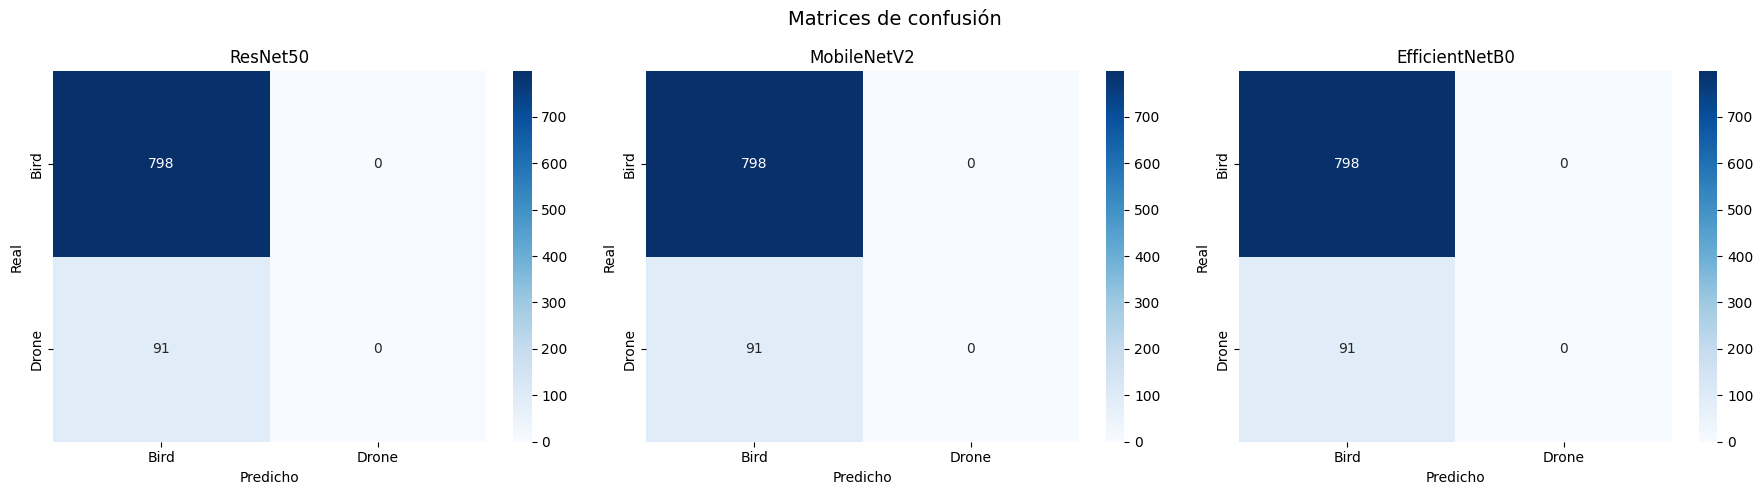

In [10]:
# ── Matrices de confusión ────────────────────────────────────────────────────
class_names = ['Bird', 'Drone']
n = len(predictions_registry)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

for ax, (model_name, preds) in zip(axes, predictions_registry.items()):
    cm = confusion_matrix(preds['y_true'], preds['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión', fontsize=14)
plt.tight_layout()
plt.show()


## Reporte de los modelos

In [ ]:


for model_name, preds in predictions_registry.items():
    y_true = np.array(preds["y_true"])
    y_pred = np.array(preds["y_pred"])

    print(f"\n=== {model_name} ===")
    print("Reales     [bird, drone]:", np.bincount(y_true, minlength=2))
    print("Predichas  [bird, drone]:", np.bincount(y_pred, minlength=2))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print("CM [[TN, FP],[FN, TP]]:\n", cm)


=== ResNet50 ===
Reales     [bird, drone]: [798  91]
Predichas  [bird, drone]: [889   0]
CM [[TN, FP],[FN, TP]]:
 [[798   0]
 [ 91   0]]

=== MobileNetV2 ===
Reales     [bird, drone]: [798  91]
Predichas  [bird, drone]: [889   0]
CM [[TN, FP],[FN, TP]]:
 [[798   0]
 [ 91   0]]

=== EfficientNetB0 ===
Reales     [bird, drone]: [798  91]
Predichas  [bird, drone]: [889   0]
CM [[TN, FP],[FN, TP]]:
 [[798   0]
 [ 91   0]]


## Conclusiones Clasificación Bird VS Drone

En base a los resultados obtenidos con ResNet50, MobileNetV2 y EfficientNetB0, se concluye que:

- El conjunto de prueba contiene 798 imágenes de `bird` y 91 de `drone` (clases reales).
- Los tres modelos solo predicen la clase mayoritaria: 889 como `bird` y 0 como `drone`.
- Esto sugiere un problema de desbalance y/o calidad de etiquetado en el dataset, por lo que la `accuracy` no refleja bien el rendimiento real.